# 🪐 Kepler Exoplanet Search — ML Pipeline

## Overview
This notebook analyzes NASA's Kepler Exoplanet Search Results dataset — a cumulative record of approximately 10,000 Kepler Objects of Interest (KOIs) observed by the Kepler Space Telescope.

The goal is to build a multi-stage pipeline that:
1. **Predicts `koi_score`** using false positive flag columns (Multiple Linear Regression)
2. **Clusters candidates** by score to see if natural groupings align with disposition labels (KMeans)
3. **Classifies `koi_disposition`** using physical measurement features (Random Forest)
4. **Validates Kepler's automated pipeline** by comparing it against scientific literature verdicts (Confusion Matrix)

### Key Columns:
| Column | Description |
|---|---|
| `koi_disposition` | Scientific verdict — CONFIRMED, FALSE POSITIVE, CANDIDATE |
| `koi_pdisposition` | Kepler's automated verdict — CANDIDATE or FALSE POSITIVE |
| `koi_score` | Confidence score (0–1) for the disposition |
| `koi_fpflag_*` | False positive flags raised by Kepler's pipeline |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/nasa/kepler-exoplanet-search-results/cumulative.csv


## 1. Setup & Imports

In [2]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


## 2. Load Dataset

In [3]:
file_path='/kaggle/input/datasets/organizations/nasa/kepler-exoplanet-search-results/cumulative.csv'
file_data=pd.read_csv(file_path)

## 3. Exploratory Data Analysis

### 3.1 Display Settings
The dataset has 50 columns. We configure pandas to display all columns so nothing is hidden during exploration.

In [4]:
import pandas as pd

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Optional: show all rows too
pd.set_option('display.width', None)        # Prevent line wrapping

### 3.2 First Look at the Data

In [5]:
file_data.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,NaN,NaN,93.59,29.45,-16.65,35.8,1.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,NaN,NaN,9.11,2.87,-1.62,25.8,2.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,NaN,NaN,39.30,31.04,-10.49,76.3,1.0,q1_q17_dr25_tce,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,NaN,NaN,891.96,668.95,-230.35,505.6,1.0,q1_q17_dr25_tce,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,NaN,NaN,926.16,874.33,-314.24,40.9,1.0,q1_q17_dr25_tce,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


### 3.3 Data Types & Null Counts
`df.info()` gives us a quick summary of column types and how many non-null values exist per column — essential before any preprocessing.

In [6]:
file_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

<Axes: xlabel='koi_disposition', ylabel='count'>

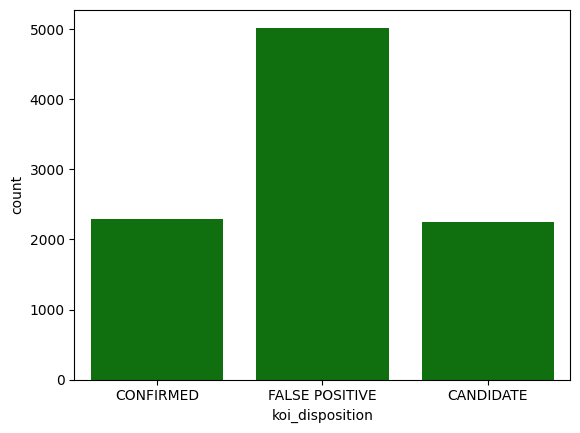

In [7]:
sns.countplot(data=file_data, x='koi_disposition',color='green')

### 3.5 Correlation Heatmap
A correlation heatmap of all numerical columns helps identify which features are strongly related to each other. High correlation between features (multicollinearity) can affect model performance and interpretability.

<Axes: >

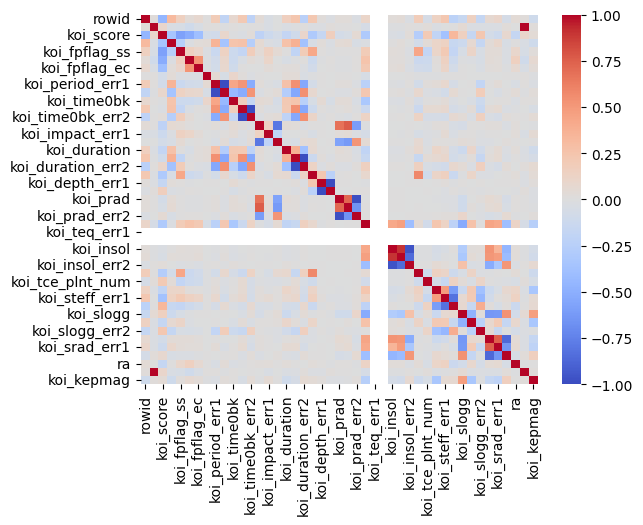

In [8]:
sns.heatmap(file_data.select_dtypes(include='number').corr(), 
            cmap='coolwarm')

### 3.6 Orbital Period Distribution by Disposition
`koi_period` represents the orbital period of the candidate planet in days. The distribution is heavily right-skewed — values range from 0.24 to nearly 130,000 days — so a log scale is applied to make the plot readable.

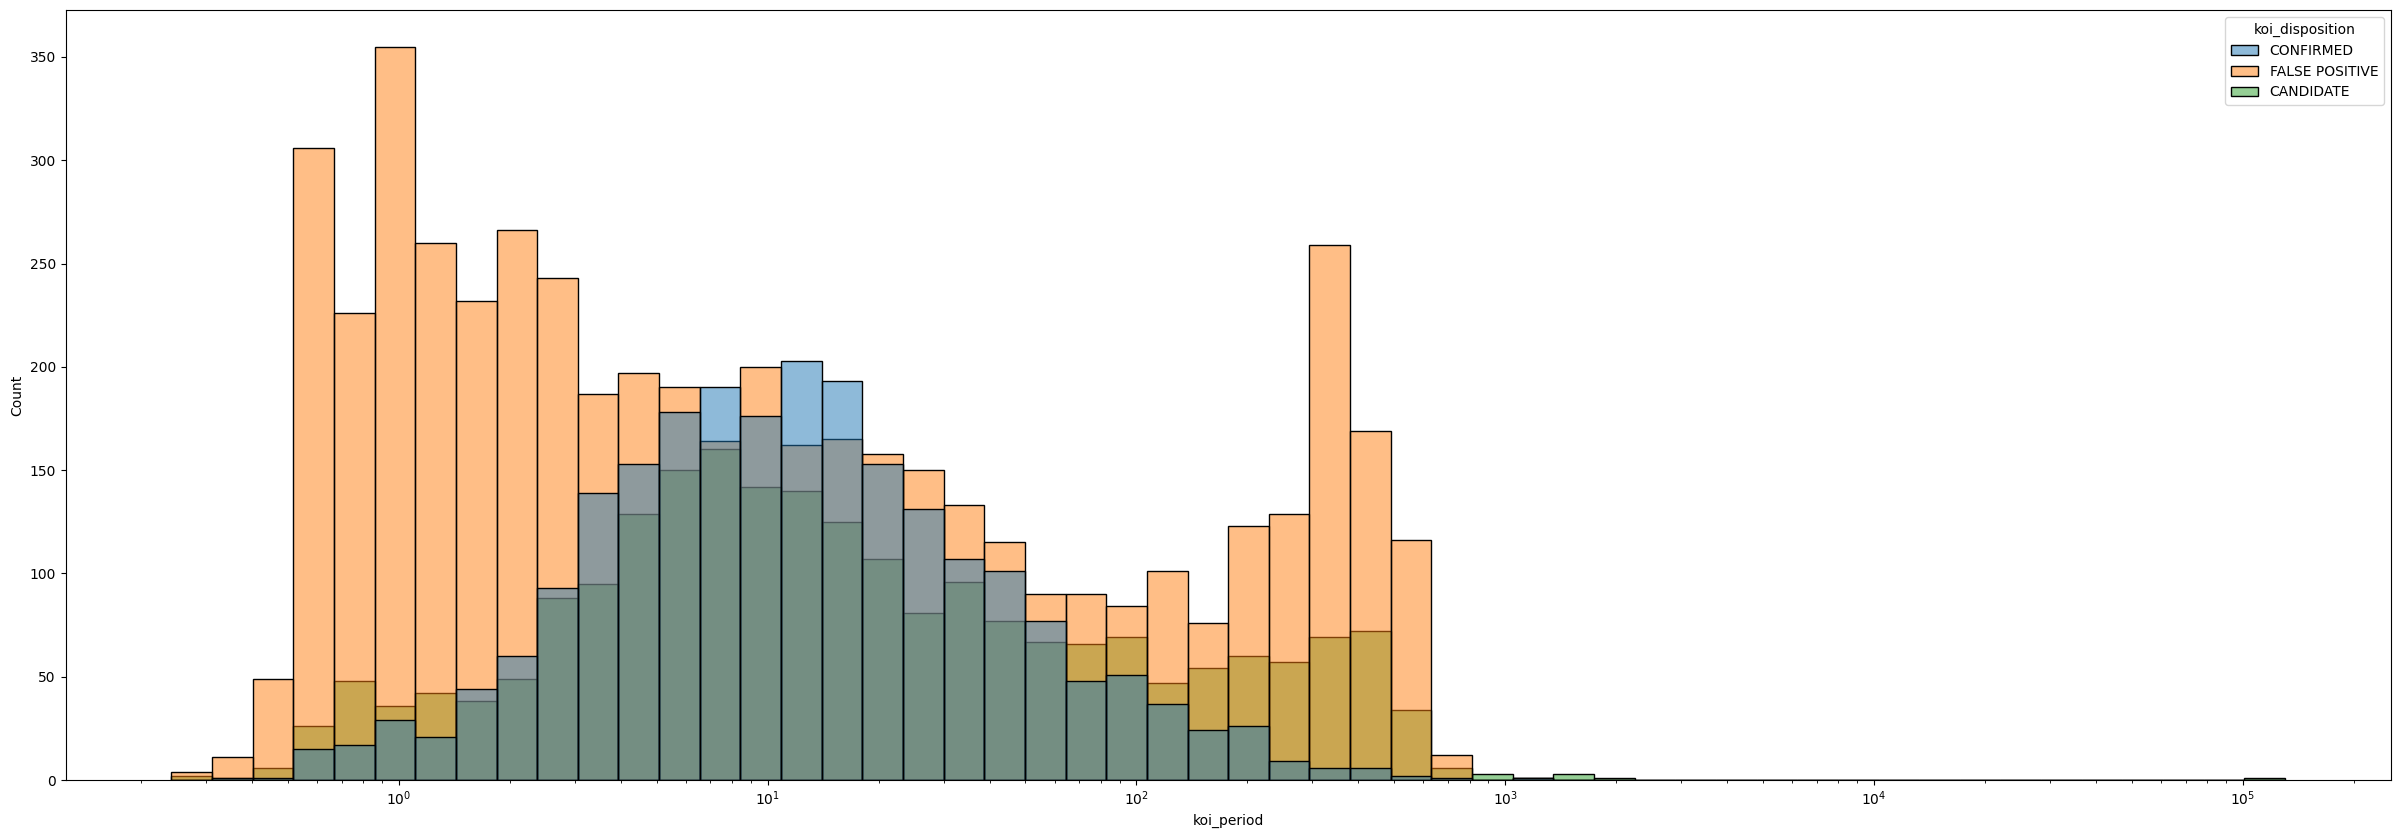

In [9]:
plt.figure(figsize=(30, 10))
sns.histplot(data=file_data, x='koi_period', hue='koi_disposition', log_scale=True)
plt.show()

### 3.7 Transit Duration Distribution by Disposition
`koi_duration` is the duration of the observed transit in hours. Like orbital period, this column is skewed and benefits from a log scale. Confirmed planets tend to have longer, more consistent transit durations compared to false positives.

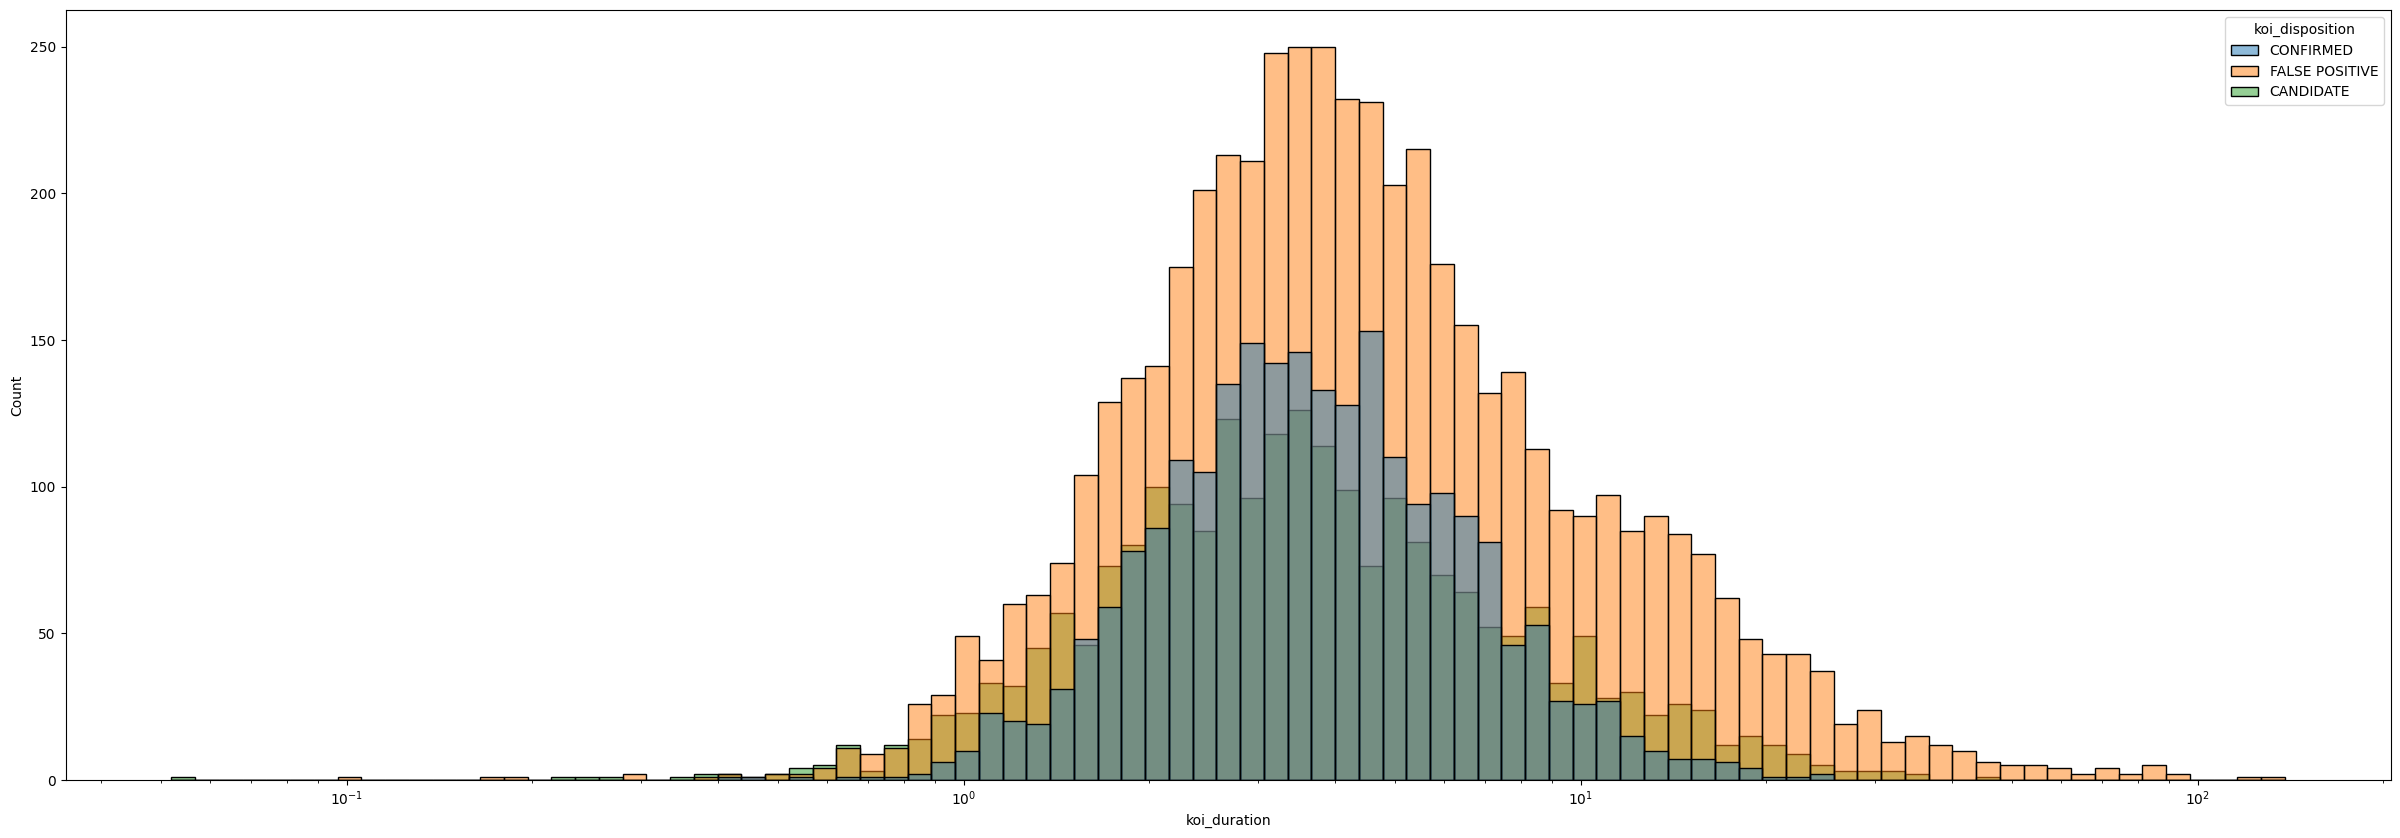

In [10]:
plt.figure(figsize=(30, 10))
sns.histplot(data=file_data, x='koi_duration', hue='koi_disposition', log_scale=True)
plt.show()

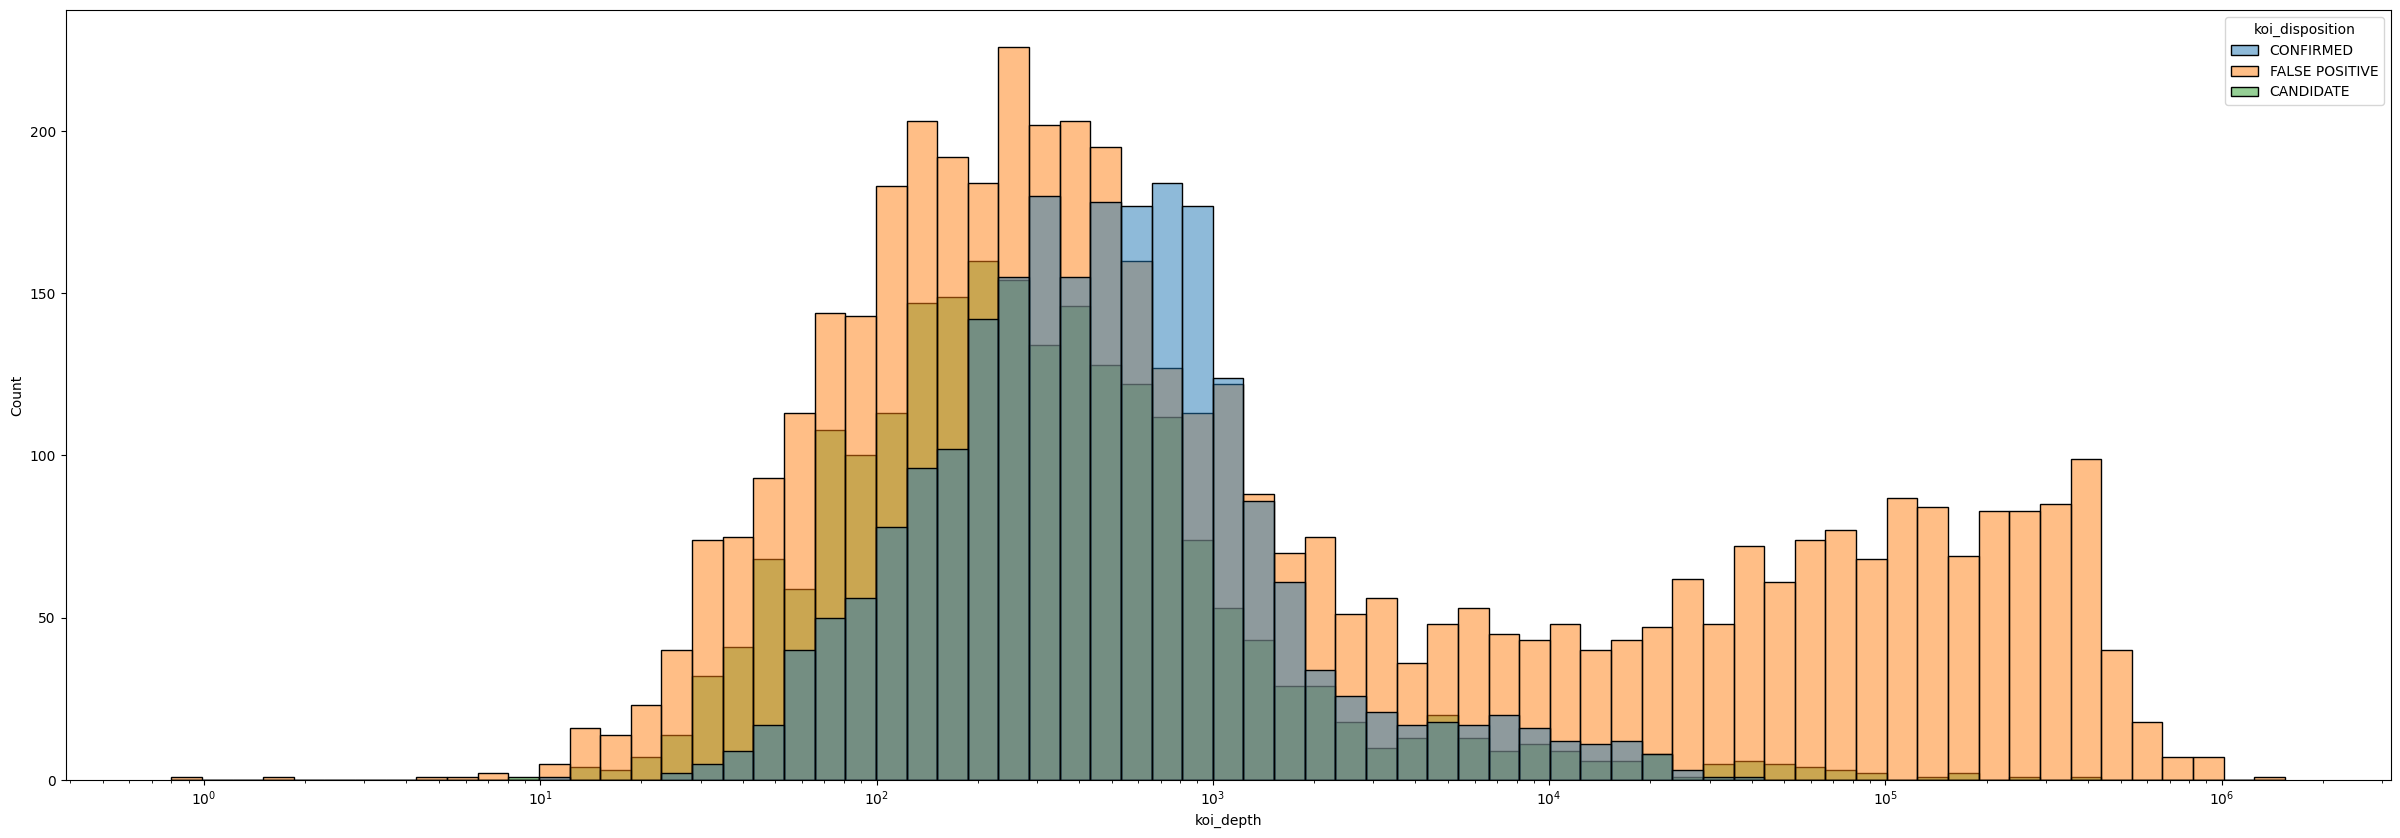

In [11]:
plt.figure(figsize=(30, 10))
sns.histplot(data=file_data, x='koi_depth', hue='koi_disposition', log_scale=True)
plt.show()

### 3.8 Transit Depth Distribution by Disposition
`koi_depth` measures how much the star's brightness dips during a transit in parts per million. Deeper transits generally indicate larger planets. Log scale is applied due to extreme outliers.

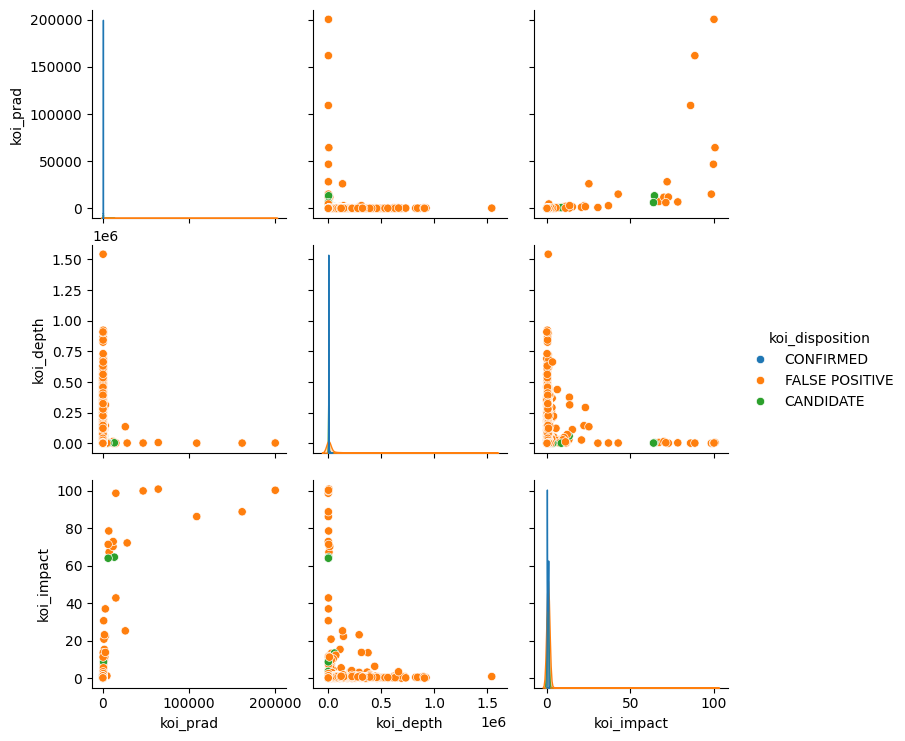

In [12]:
sns.pairplot(file_data[['koi_prad', 'koi_depth', 'koi_impact', 'koi_disposition']], 
             hue='koi_disposition')

### 3.10 Confidence Score by Disposition
`koi_score` is Kepler's confidence score for each disposition. A boxplot reveals how this score is distributed across CONFIRMED, FALSE POSITIVE, and CANDIDATE classes. We expect confirmed planets to cluster near 1.0 and false positives near 0.0.

<Axes: xlabel='koi_disposition', ylabel='koi_score'>

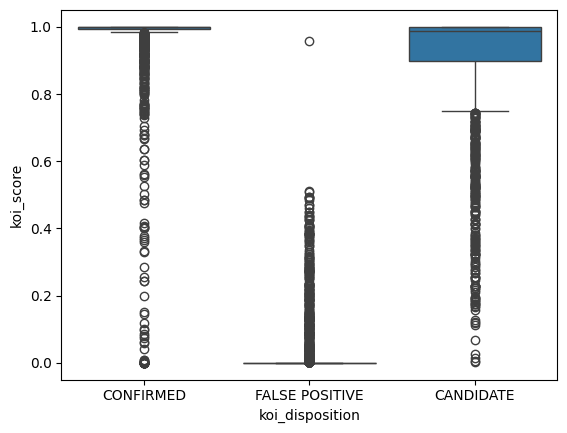

In [13]:
sns.boxplot(data=file_data, x='koi_disposition', y='koi_score')

---
## 4. Step 1 — Multiple Linear Regression: Predicting `koi_score`

### Hypothesis
The four false positive flags are raised by Kepler's pipeline when a candidate shows signs of being a false positive. Since `koi_score` reflects confidence in the disposition, these flags should be strong predictors of the score.

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score

### Training the Regression Model
We drop rows where `koi_score` is null, then train a Multiple Linear Regression model using the 4 flag columns as features and an 80/20 train/test split.

In [15]:
file_data.dropna(subset=['koi_score'], inplace=True)
x = file_data[['koi_fpflag_nt','koi_fpflag_ss','koi_fpflag_co','koi_fpflag_ec']] 
y = file_data['koi_score'] 
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x,y)

LinearRegression()

### Predictions vs Actual Values

In [16]:
y_pred=model.predict(x_test)
print("Predictions:", y_pred)
print("Actual:", y_test)

Predictions: [ 0.43871412  0.19321765 -0.23867306 ...  0.17508208  0.85246925
  0.85246925]
Actual: 2849    0.014
7489    0.000
2118    0.000
7004    0.000
3452    0.027
2195    0.015
7880    0.984
226     1.000
6652    0.000
6622    1.000
3234    1.000
8545    0.001
5182    0.001
6063    0.000
3467    0.000
4213    0.000
7342    0.001
9500    0.116
2770    0.951
7564    0.000
6312    0.643
2847    0.997
1128    1.000
4900    0.000
493     0.985
3304    0.000
3596    0.989
2608    0.000
2635    0.000
6759    0.000
6852    0.858
3215    0.000
9350    0.000
6559    1.000
3102    1.000
1737    1.000
8884    0.769
5569    1.000
2540    1.000
8180    0.998
3350    1.000
9556    0.000
1656    1.000
9010    0.079
3042    0.994
9229    0.978
3440    1.000
6947    0.000
8265    0.000
9424    0.000
656     0.000
2222    0.000
4853    1.000
1008    1.000
1889    0.485
1959    0.993
2978    0.001
781     0.000
3320    0.996
3697    0.000
2148    0.951
7769    0.000
6802    0.902
2983    1.000
3624

### Regression Results
- **R² = 0.755** — the 4 flag columns explain 75.5% of the variance in `koi_score`
- **RMSE = 0.2** — predictions are off by 0.2 on average on a 0–1 scale — acceptable for this stage

In [17]:

print(f"Max R²: {r2_score(y_test, y_pred):.3f}")
print(f"Max RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.1f}")


Max R²: 0.755
Max RMSE: 0.2


---
## 5. Step 2 — KMeans Clustering: Do Scores Naturally Separate Dispositions?

### Hypothesis
If `koi_score` truly reflects the nature of a candidate, clustering it into 2 groups without any labels should naturally produce one cluster of CANDIDATEs and one of FALSE POSITIVEs.

### Checking `koi_pdisposition` Distribution

In [18]:
print(file_data['koi_pdisposition'].value_counts())


koi_pdisposition
CANDIDATE         4034
FALSE POSITIVE    4020
Name: count, dtype: int64


### Outlier Check on Key Features
Before clustering, we check the distribution of top features to understand the scale and spread of the data.

In [19]:
file_data[['koi_prad', 'koi_depth', 'koi_score']].describe()

,koi_prad,koi_depth,koi_score
count,7995.000000,7995.000000,8054.000000
mean,27.920837,26649.992683,0.480829
std,312.072761,85043.051336,0.476928
min,0.080000,0.000000,0.000000
25%,1.410000,162.400000,0.000000
50%,2.470000,449.200000,0.334000
75%,19.745000,2000.200000,0.998000
max,26042.900000,921670.000000,1.000000


### Finding Optimal k — Elbow Method
Rather than assuming k=2 arbitrarily, we use the elbow method to find where adding more clusters stops significantly reducing inertia. The sharp turn at k=2 confirms our choice.

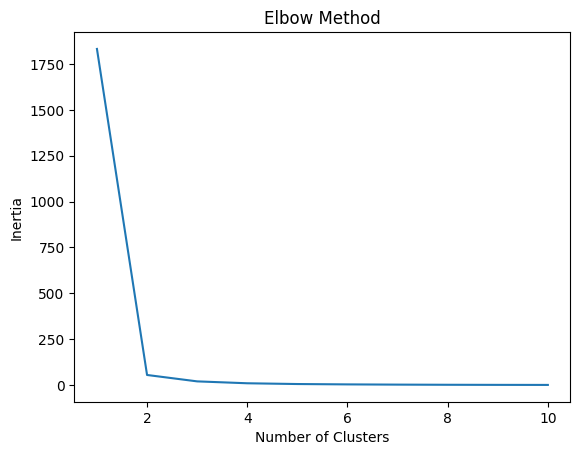

In [20]:
from sklearn.cluster import KMeans
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(file_data[['koi_score']])
    inertia.append(kmeans.inertia_) 

plt.plot(k_range, inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [21]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(file_data[['koi_score']])

KMeans(n_clusters=2, random_state=42)

### Clustering Results
We assign cluster labels back to the dataframe and compare against `koi_pdisposition` to validate the natural groupings.

**Finding:** Cluster 0 captured almost exclusively CANDIDATEs (3919 vs 3 false positives) and Cluster 1 captured almost exclusively FALSE POSITIVEs (4017 vs 115 candidates) — confirming that `koi_score` alone is a strong natural separator.

In [22]:
file_data['cluster'] = kmeans.labels_
print(file_data.groupby(['cluster', 'koi_pdisposition']).size())

cluster  koi_pdisposition
0        CANDIDATE           3919
         FALSE POSITIVE         3
1        CANDIDATE            115
         FALSE POSITIVE      4017
dtype: int64


---
## 6. Step 3 — Random Forest Classification: Predicting `koi_disposition`

### Encoding the Target Variable
Random Forest requires numerical inputs. We encode `koi_disposition` as:
- `FALSE POSITIVE` → 0
- `CONFIRMED` → 1
- `CANDIDATE` → 2

In [23]:
file_data['koi_disposition_encoded'] = file_data['koi_disposition'].map({'CONFIRMED':1, 'FALSE POSITIVE':0, 'CANDIDATE':2})
print(file_data[['koi_disposition', 'koi_disposition_encoded']].head(10))

  koi_disposition  koi_disposition_encoded
0       CONFIRMED                        1
1       CONFIRMED                        1
2  FALSE POSITIVE                        0
3  FALSE POSITIVE                        0
4       CONFIRMED                        1
5       CONFIRMED                        1
6       CONFIRMED                        1
7       CONFIRMED                        1
8  FALSE POSITIVE                        0
9       CONFIRMED                        1


### Feature Selection & Train/Test Split
We use 11 physical measurement columns as features — orbital and stellar properties. We deliberately exclude `koi_score` and `koi_pdisposition` to avoid data leakage, since those are derived from the same pipeline we are evaluating.

In [24]:
X=file_data[['koi_period' ,'koi_time0bk' ,'koi_impact' ,'koi_duration' ,
             'koi_depth' ,'koi_prad' ,'koi_teq' ,'koi_insol',
             'koi_srad', 'koi_slogg', 'koi_steff']]
Y=file_data['koi_disposition_encoded']
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

### Model Evaluation
Training with 500 estimators. Results:
- Overall accuracy: **75.6%**
- FALSE POSITIVE: Strong — F1 = 0.86
- CONFIRMED: Decent — F1 = 0.74
- CANDIDATE: Weakest — F1 = 0.49, expected since candidates are inherently uncertain and sit between the other two classes

In [25]:
Y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(Y_test,Y_pred ))
print(classification_report(Y_test,Y_pred ))

0.7535692116697703
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       811
           1       0.69      0.79      0.74       453
           2       0.56      0.42      0.48       347

    accuracy                           0.75      1611
   macro avg       0.70      0.70      0.69      1611
weighted avg       0.74      0.75      0.75      1611



---
## 7. Step 4 — Confusion Matrix: Automated Pipeline vs Scientific Literature

### Hypothesis
`koi_pdisposition` is Kepler's automated verdict. `koi_disposition` is what the scientific community concluded. How well do they agree — and where does the automated system fail?

### Encoding `koi_pdisposition`
`koi_pdisposition` only has two classes — CANDIDATE and FALSE POSITIVE — unlike `koi_disposition` which also includes CONFIRMED.

In [26]:
file_data['koi_pdisposition_encoded'] = file_data['koi_pdisposition'].map({'FALSE POSITIVE':0, 'CANDIDATE':1})


### Confusion Matrix Results

**Key Finding:**
- **3976 FALSE POSITIVEs** — perfect agreement between automated and scientific verdict ✅
- **2237 CONFIRMED planets** — correctly identified as CANDIDATEs by the automated system ✅
- **44 CONFIRMED planets** — flagged as FALSE POSITIVE by Kepler's automated pipeline ⚠️

These 44 planets are the most significant finding of this project — real confirmed planets that Kepler's automated system nearly dismissed. This highlights the critical importance of human scientific review on top of automated pipelines.

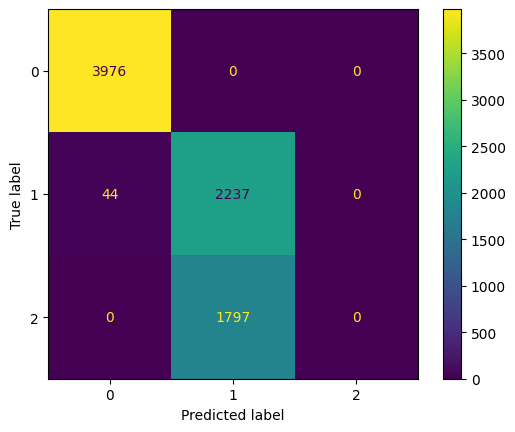

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(file_data['koi_disposition_encoded'], file_data['koi_pdisposition_encoded'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

---
## 8. Conclusion

This project built a 4-stage ML pipeline on NASA's Kepler dataset:

| Step | Method | Result |
|---|---|---|
| Predict `koi_score` | Multiple Linear Regression | R²=0.755, RMSE=0.2 |
| Cluster by score | KMeans (k=2) | Natural separation confirmed |
| Classify `koi_disposition` | Random Forest | 75.6% accuracy |
| Validate automated pipeline | Confusion Matrix | 44 confirmed planets nearly missed |

**The most important finding:** Kepler's automated pipeline flagged 44 scientifically confirmed planets as false positives — underlining why automated systems always need human validation, especially in high-stakes scientific discovery.